**Import Required Libraries**

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

**Load Dataset**

In [28]:
df = pd.read_csv('/content/customer_shopping_data.csv')
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


**Exploratory Data Analysis (EDA)**

Basic Info

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


In [30]:
df.describe()

,age,quantity,price
count,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321
std,14.990054,1.413025,941.184567
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,69.000000,5.000000,5250.000000


Check Missing Values

In [31]:
df.isnull().sum()

,0
invoice_no,0
customer_id,0
gender,0
age,0
category,0
quantity,0
price,0
payment_method,0
invoice_date,0
shopping_mall,0


**Data Visualization**

Gender Distribution

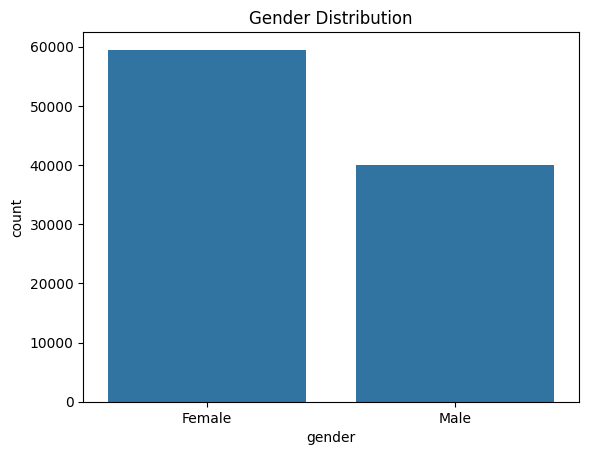

In [32]:
sns.countplot(x='gender', data=df)
plt.title('Gender Distribution')
plt.show()

Age Distribution

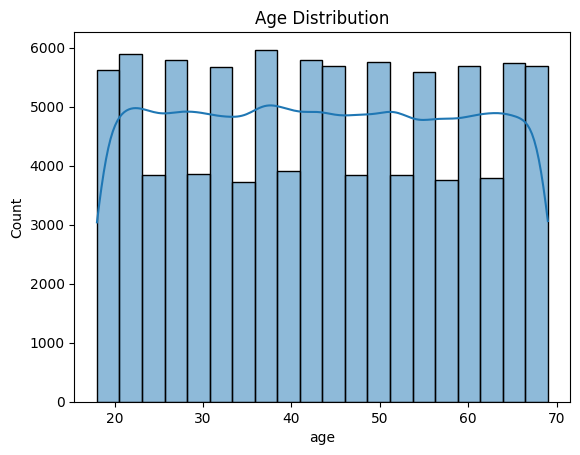

In [33]:
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

Annual Income vs Spending Score

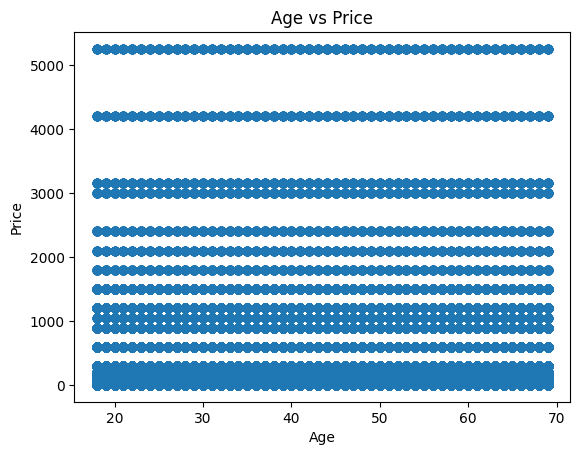

In [34]:
plt.scatter(df['age'], df['price'])
plt.xlabel('Age')
plt.ylabel('Price')
plt.title('Age vs Price')
plt.show()

**Data Preprocessing**

Encode Gender

In [35]:
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})

Select Features

In [36]:
X = df[['age', 'quantity', 'price']]

Feature Scaling

In [37]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Clusters (Elbow Method)**

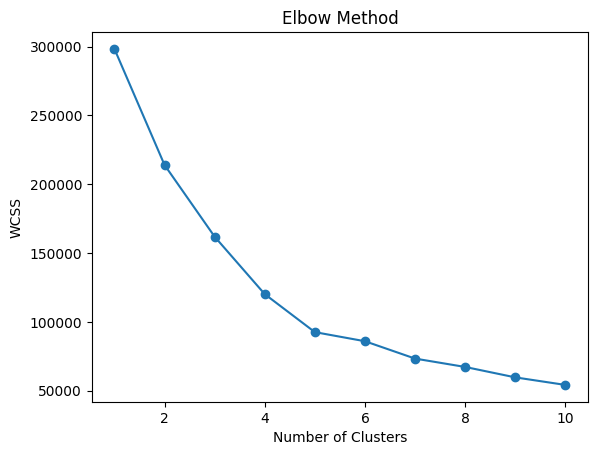

In [38]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

**K-Means Clustering**

In [39]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters


**Visualize Clusters**

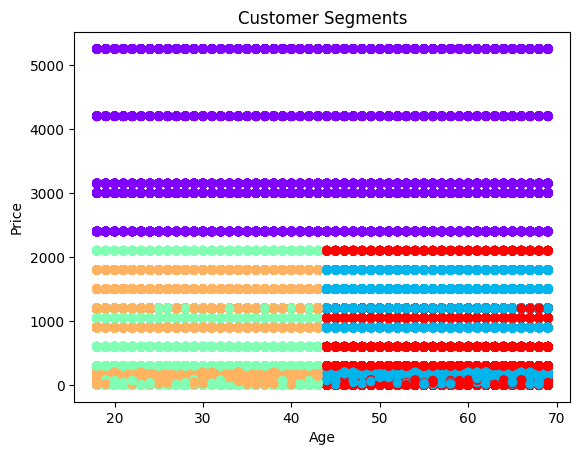

In [40]:
plt.scatter(df['age'], df['price'], c=df['Cluster'], cmap='rainbow')
plt.xlabel('Age')
plt.ylabel('Price')
plt.title('Customer Segments')
plt.show()

**PCA for Dimensionality Reduction**

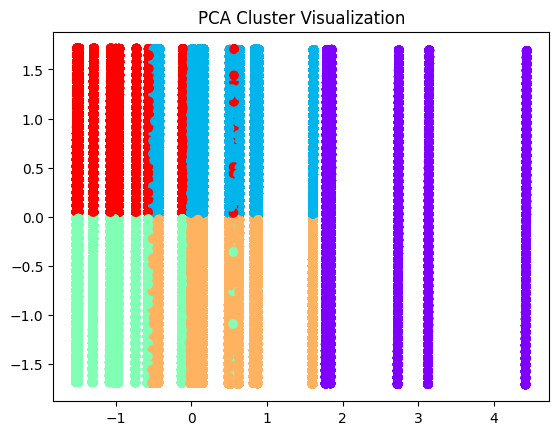

In [41]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'], cmap='rainbow')
plt.title('PCA Cluster Visualization')
plt.show()

**Cluster Analysis**

In [42]:
df.groupby('Cluster').mean(numeric_only=True)

,gender,age,quantity,price
Cluster,,,,
0,0.594238,43.469344,4.284559,3339.864605
1,0.597244,56.514143,3.959576,595.396776
2,0.592667,30.514063,1.498995,345.890964
3,0.601563,30.537173,3.958488,591.286664
4,0.601270,56.486563,1.502565,345.182715


**Marketing Strategies**

Cluster 0:
High Income – High Spending
Premium customers
Strategy:


*  Luxury promotions



*  Exclusive memberships


*   Personalized offers









Cluster 1: Low Income – High Spending
Impulsive buyers
Strategy:


*   Discounts & deals
*   Limited-time offers

*   Coupons








Cluster 2: High Income – Low Spending
Careful customers
Strategy:


*   Awareness campaigns

*   Product education
*   Value-based marketing






Cluster 3: Low Income – Low Spending
Budget customers
Strategy:


*   Basic affordable products
*   Bundle offers





Cluster 4: Average Customers
Moderate income & spending
Strategy:


*   Loyalty programs
*   Seasonal offers



